# Decision Tree Classifier Implementation

This notebook implements a Decision Tree Classifier on the **Breast Cancer Wisconsin** Dataset from `sklearn`.

## Problem Statement
Try to fine-tune which parameters work best for the Breast Cancer Wisconsin Dataset. Create a concise report with charts showing Hyper-parameter v/s Accuracy/Loss. This will be done separately for each hyper-parameter, and combined effects will be neglected. Preferably split the data and use k-fold cross validation.

## Aim of the Notebook
The task is to study how a few important hyperparameters affects model performance, one at a time, using:-
* a test/train split
* **k-fold cross validation** on the training data
* **accuracy** and **log loss** as evaluation metrics
* clear charts for each tuning study
  
**NOTE:** The word `loss` in the notebook refers to the `log loss` computed from *predicted class probabilities*.

## Notebook Structure
This notebook is divided into multiple sections for simplicity and readability. Each section will aim to achieve a particular new feature which is mentioned as the name of the section. The section names are as follow:
```
1. Dataset Loading and Initial Exploration 
2. Data Preparation and Train/Test Split  
3. Baseline Decision Tree  
4. Baseline Tree Visualisation
5. K-Fold Cross Validation Setup
6. Hyperparameter Study 1: Criterion (Gini v/s Entropy)
7. Hyperparameter Study 2: Maximum Depth
8. Hyperparameter Study 3: Maximum Leaf Nodes
9. Hyperparameter Study 4: `min_samples_split`
10. Hyperparameter Study 5: `min_samples_leaf`
11. Summary of Hyperparameter Results
12. Final Tuned Model
13. General Resources
```

## Section Structure
Each section will follow similar base structure mentioned below
* References
* Code
* Write-Up (Explaining inferences or functions of the codes written in that section)

# 1. Dataset Loading and Initial Exploration

## References
* https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

## Code

In [1]:
# Import pandas module and breast cancer dataset
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

# Create pandas dataframe
df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

df["target"] = cancer.target

# Output the head to get an idea of Dataset structure
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
# Now we know the general structure of the dataset
# But I'll just get it in a clean way

print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  s

In [3]:
# So now we know the shape of the dataset: (569, 31)
# I'm now going to describe the dataset (Not necessary but more like a standard practice)

df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:
# Now let's understand the distribution of classes

df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [5]:
# Now let's check for missing values in the dataset
# df.isnull() creates a dataframe with boolean values, sum() will return number of missing values in each column
# sum() again will take sum of column-wise outputs and thus show total NaN values in df

missing_values = df.isnull().sum().sum()

if missing_values == 0:
    print("No missing values found.")
else:
    print(f"Dataset contains {missing_values} missing values.")

No missing values found.


## Write-Up
* Loaded the Breast Cancer Wisconsin dataset directly from sklearn.
* Converted dataset into a pandas DataFrame.
* Checked Dataset dimensions, feature types and target distribution.
* Verified that there are no missing values.

# 2. Data Preparation and Train-Test Split

## References
* https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

## Code

In [6]:
# We'll now require to split the data into testing and training data, so I'm going to import another module
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

# Split the data such that 80% is used for training

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print out the shapes for verification
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


## Write-Up
* Split dataset into training and testing sets, with the dimensions printed out above.
* Used `stratification` to preserve class proportions.
* Test set will be used only for final evaluation, train set will be used further for training.

# 3. Baseline Decision Tree

## References
* https://scikit-learn.org/stable/modules/tree.html

## Code

In [7]:
# Import Decision Tree Classifier and perform further operations
from sklearn.tree import DecisionTreeClassifier
baseline_tree = DecisionTreeClassifier(random_state=42)
baseline_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
# For the next step we require to compute accuracy score and log loss
# I'll just import those from scikit-learn itself

from sklearn.metrics import accuracy_score, log_loss

# Run a prediction on the training data using baseline tree
y_pred = baseline_tree.predict(X_test)
y_prob = baseline_tree.predict_proba(X_test) # Probabilities for log loss

# Find accuracy and loss for this prediction
baseline_acc = accuracy_score(y_test, y_pred)
baseline_loss = log_loss(y_test, y_prob)

# Print them out so we can see what's going on
print("Accuracy:", baseline_acc)
print("Los loss:", baseline_loss)

Accuracy: 0.9122807017543859
Los loss: 3.1617239815015044


## Write-Up
* Trained a *default* decision tree.
* This provides a baseline for comparison.
* Future hyperparameter experiments will be compared against these metrics.

# 4. Baseline Tree Visualisation

## References
* https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html

## Code

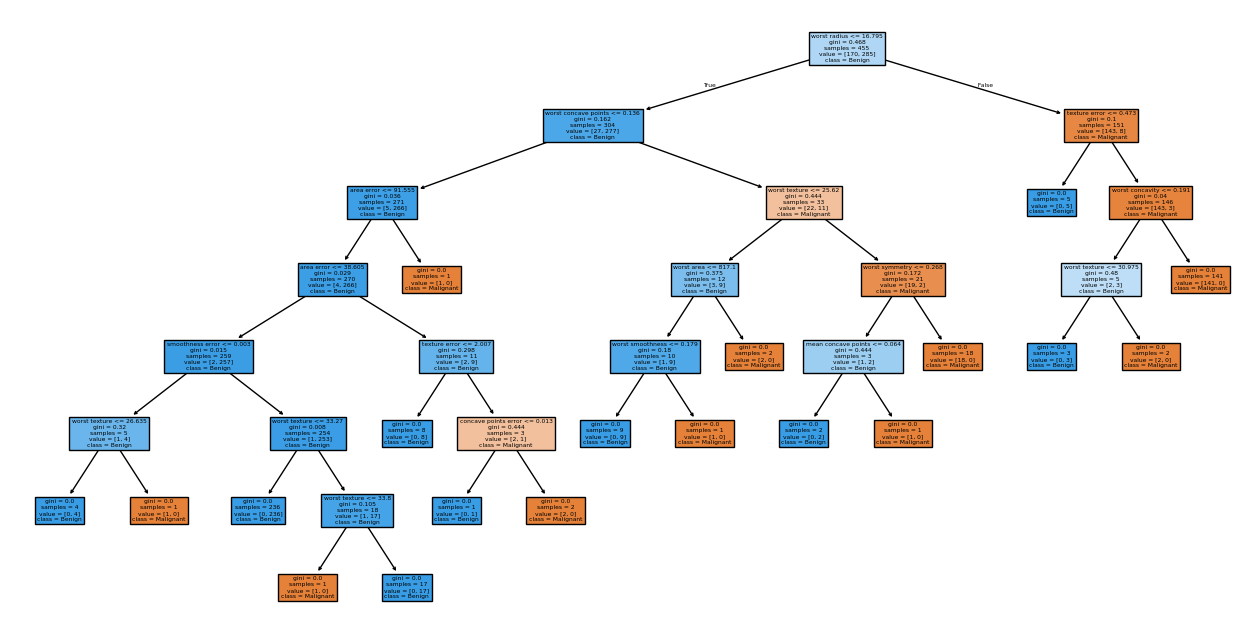

In [9]:
# We're visualising using matplotlib so let's import that first
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))

#Plot the tree
plot_tree(
    baseline_tree,
    filled=True,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"]
)

plt.show()

## Write-Up
* Visualised the *untuned* decision tree.
* We can get an idea of the model's complexity looking at the tree.
* Tree appears very large, indicating potential overfitting.

# 5. K-Fold Cross Validation Step

## References
* https://scikit-learn.org/stable/modules/cross_validation.html

## Code

In [10]:
# Import module for stratified k fold implementation
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Write-Up
* Created a k-fold stratified cross-validation object (k=5).
* Ensures more reliable evaluation than a single train-test split.

# 6. Hyperparameter Study 1: Criterion (Gini v/s Entropy)

## References
* Decision Tree Documentation

## Code

In [11]:
# Import necessary modules
from sklearn.model_selection import cross_val_score
import numpy as np

# Create necessary data structures for storage, I'm using lists
criteria = ["gini", "entropy"]

criterion_acc = []
criterion_loss = []

# Compute for both criteria

for criterion in criteria:

    model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=42
    )

# Generate accuracy and loss
    
    acc = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()

    loss = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_log_loss"
    ).mean()

    criterion_acc.append(acc)
    criterion_loss.append(loss)

    print(criterion, acc, loss)

gini 0.9164835164835164 3.010239184146048
entropy 0.9296703296703296 2.534938260333514


## Code (Plots)

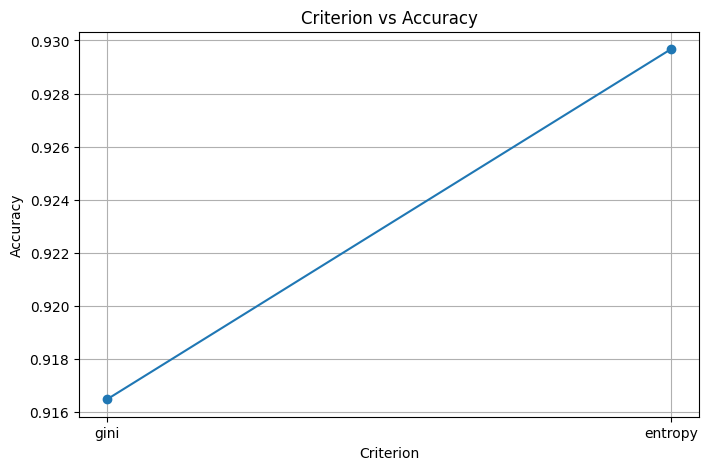

In [12]:
# Plot the graph of criterion v/s accuracy

plt.figure(figsize=(8,5))
plt.plot(criteria, criterion_acc, marker="o")
plt.title("Criterion vs Accuracy")
plt.xlabel("Criterion")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

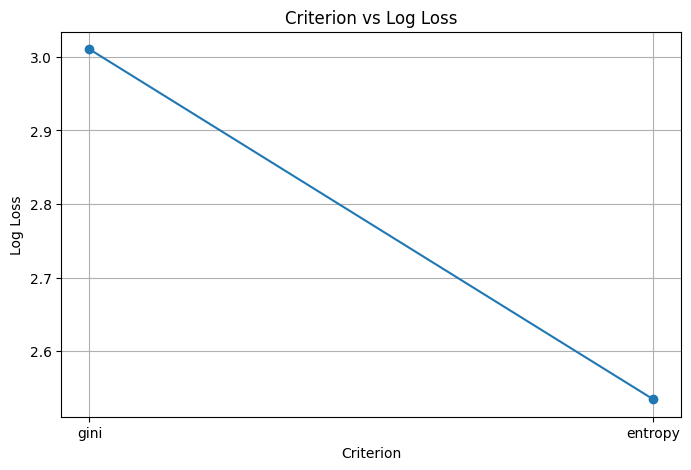

In [13]:
# Plot the graph of criterion v/s loss

plt.figure(figsize=(8,5))
plt.plot(criteria, criterion_loss, marker="o")
plt.title("Criterion vs Log Loss")
plt.xlabel("Criterion")
plt.ylabel("Log Loss")
plt.grid()
plt.show()

## Write-Up
* Compared Gini and Entropy splitting criteria.
* Evaluated using 5-fold cross-validation.
* Observed which criterion produced **higher accuracy** and **lower log-loss**.

# 7. Hyperparameter Study 2: Maximum Depth

## References
* Decision Tree Documentation

## Code

In [14]:
# Create a range object for depths
depths = range(1, 21)

# Create necessary data structures, I'm using lists again
depth_acc = []
depth_loss = []

# Run the main loop
for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

# Generate accuracy and loss, and append to list
    acc = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()

    loss = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_log_loss"
    ).mean()

    depth_acc.append(acc)
    depth_loss.append(loss)

    print(depth, acc, loss)

1 0.9032967032967033 0.32434025874391953
2 0.9318681318681319 0.2501191842505226
3 0.9252747252747253 1.1921353943669026
4 0.9296703296703297 1.7669001625963137
5 0.9230769230769231 2.03381290415933
6 0.9252747252747253 2.4888925856970525
7 0.9230769230769231 2.5708175536271343
8 0.9230769230769231 2.773853258821987
9 0.9164835164835164 3.010239184146048
10 0.9164835164835164 3.010239184146048
11 0.9164835164835164 3.010239184146048
12 0.9164835164835164 3.010239184146048
13 0.9164835164835164 3.010239184146048
14 0.9164835164835164 3.010239184146048
15 0.9164835164835164 3.010239184146048
16 0.9164835164835164 3.010239184146048
17 0.9164835164835164 3.010239184146048
18 0.9164835164835164 3.010239184146048
19 0.9164835164835164 3.010239184146048
20 0.9164835164835164 3.010239184146048


## Code (Plots)

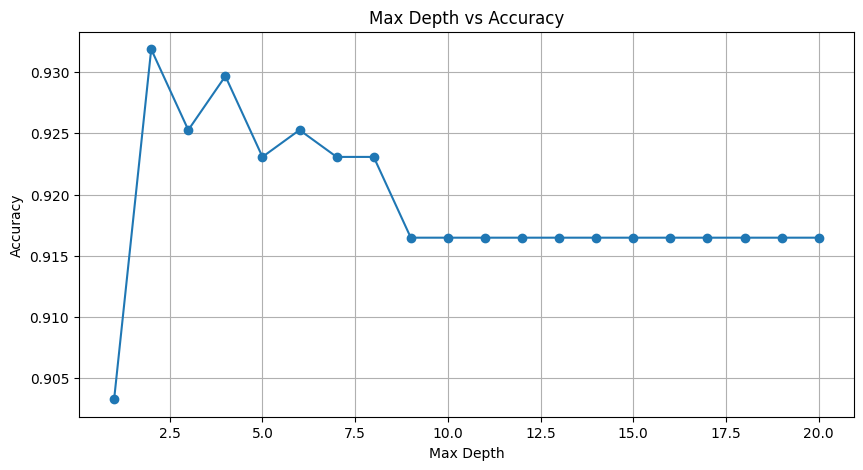

In [15]:
# Now that we've seen the numbers, let's visualise it.
# Plot a graph of Max Depth v/s Accuracy

plt.figure(figsize=(10,5))
plt.plot(depths, depth_acc, marker="o")
plt.title("Max Depth vs Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

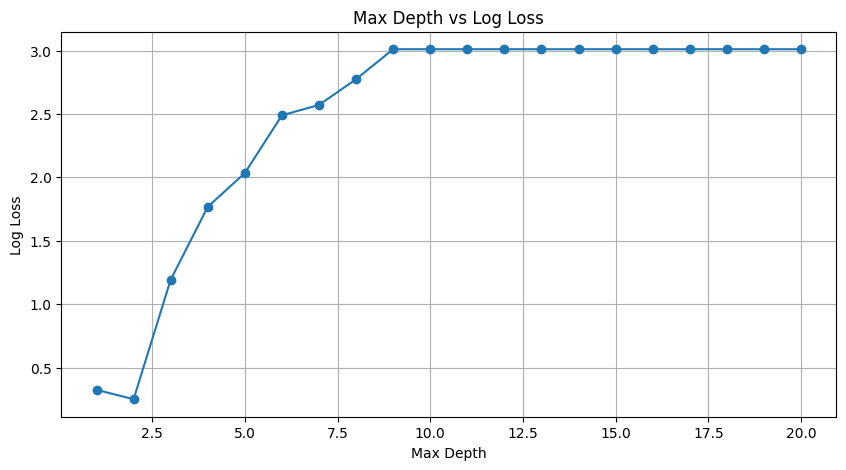

In [16]:
# Plot the graph of Max depth v/s log loss

plt.figure(figsize=(10,5))
plt.plot(depths, depth_loss, marker="o")
plt.title("Max Depth vs Log Loss")
plt.xlabel("Max Depth")
plt.ylabel("Log Loss")
plt.grid()
plt.show()

## Write-Up
* Studied how tree depth affects performance.
* Small depths may underfit, and large depths may overfit.
* Best depth corresponds to *highest validation accuracy* and *lowest loss*.

# 8. Hyperparameter Study 3: Maximum Leaf Nodes

## References
* Decision Tree Documentation

## Code

In [17]:
# Create range object for leaf nodes
leaf_nodes = range(2, 31)

# Create necessary data structures, I'm using lists
leaf_acc = []
leaf_loss = []

# Run the main loop and evaluate for each maximum leaf node value
for leaves in leaf_nodes:

    model = DecisionTreeClassifier(
        max_leaf_nodes=leaves,
        random_state=42
    )

# Generate the accuracy and loss, and append into lists
    acc = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()

    loss = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_log_loss"
    ).mean()

    leaf_acc.append(acc)
    leaf_loss.append(loss)

    print(leaves, acc, loss)

2 0.9032967032967033 0.32434025874391953
3 0.9296703296703297 0.2616045280516627
4 0.9296703296703297 0.2515982990139908
5 0.9274725274725275 0.5510210190573831
6 0.9252747252747253 0.772961060628139
7 0.9252747252747253 0.9200237568327744
8 0.9274725274725275 0.9979367712580297
9 0.9252747252747253 1.2176055151966736
10 0.9296703296703297 1.4380593625720504
11 0.9274725274725275 1.7109363474063972
12 0.9274725274725275 2.0600529575870277
13 0.9186813186813187 2.1441599583250186
14 0.9252747252747253 2.2829326343527026
15 0.9186813186813187 2.596483880890921
16 0.9164835164835164 2.735465856350694
17 0.9164835164835164 3.010239184146048
18 0.9164835164835164 3.010239184146048
19 0.9164835164835164 3.010239184146048
20 0.9164835164835164 3.010239184146048
21 0.9164835164835164 3.010239184146048
22 0.9164835164835164 3.010239184146048
23 0.9164835164835164 3.010239184146048
24 0.9164835164835164 3.010239184146048
25 0.9164835164835164 3.010239184146048
26 0.9164835164835164 3.01023918414

## Code (Plots)

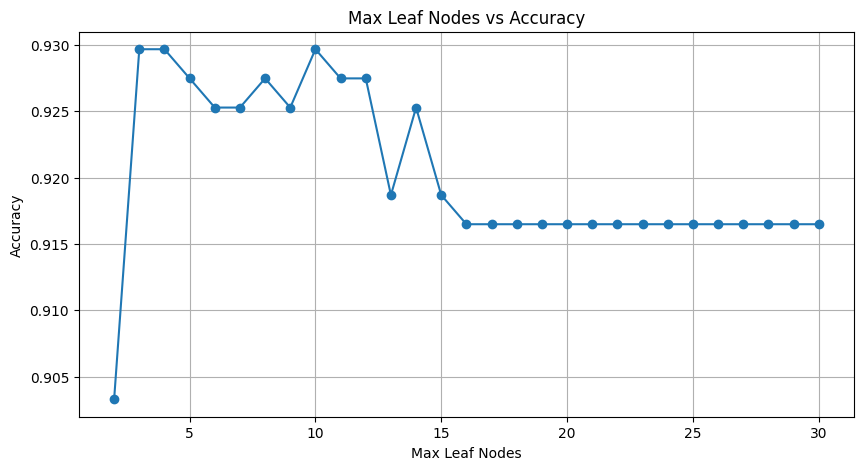

In [18]:
# Now that we've seen the numbers, let's go ahead and plot it...
# Plot Max Leaf Nodes v/s Accuracy

plt.figure(figsize=(10,5))
plt.plot(leaf_nodes, leaf_acc, marker="o")
plt.title("Max Leaf Nodes vs Accuracy")
plt.xlabel("Max Leaf Nodes")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

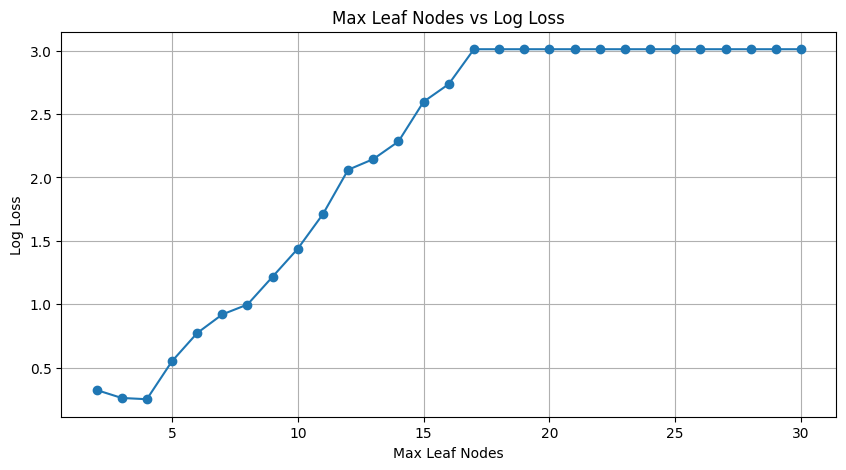

In [19]:
# Plot Max Leaf Nodes v/s Loss

plt.figure(figsize=(10,5))
plt.plot(leaf_nodes, leaf_loss, marker="o")
plt.title("Max Leaf Nodes vs Log Loss")
plt.xlabel("Max Leaf Nodes")
plt.ylabel("Log Loss")
plt.grid()
plt.show()

## Write-Up
* Evaluated impact of limiting leaf nodes.
* Restricting leaf nodes reduces model complexity.
* Optimal number of leaves can be determined using validation metrics.

# 9. Hyperparameter Study 4: `min_samples_split`
## (Minimum Samples Required to Split a Node)

## References
* Decision Tree Documentation

## Code

In [20]:
# Create range object for the split-values
split_values = range(2, 21)

# Create necessary data structures, I'm using lists again :)
split_acc = []
split_loss = []

# Run the for loop to iterate over split-values
for split in split_values:

    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )

# Generate accuracy and loss and append them into lists
    acc = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()

    loss = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_log_loss"
    ).mean()

    split_acc.append(acc)
    split_loss.append(loss)

    print(split, acc, loss)

2 0.9164835164835164 3.010239184146048
3 0.9142857142857143 2.935592564701131
4 0.9120879120879121 2.8620959411765754
5 0.9186813186813186 2.55143680088407
6 0.9208791208791209 2.3198278163308195
7 0.9186813186813186 2.0108363995879346
8 0.9186813186813186 2.0891176865630814
9 0.9186813186813186 2.0891176865630814
10 0.9186813186813186 2.0891176865630814
11 0.9186813186813186 2.013928517496337
12 0.9186813186813186 2.013928517496337
13 0.9186813186813186 2.013928517496337
14 0.9208791208791208 1.8620117177547868
15 0.923076923076923 1.7105183251316152
16 0.9186813186813186 1.639044401612199
17 0.9186813186813186 1.4921555265220694
18 0.9186813186813186 1.4921555265220694
19 0.9164835164835164 1.4221858369854912
20 0.9164835164835164 1.4242057593124293


## Code (Plots)

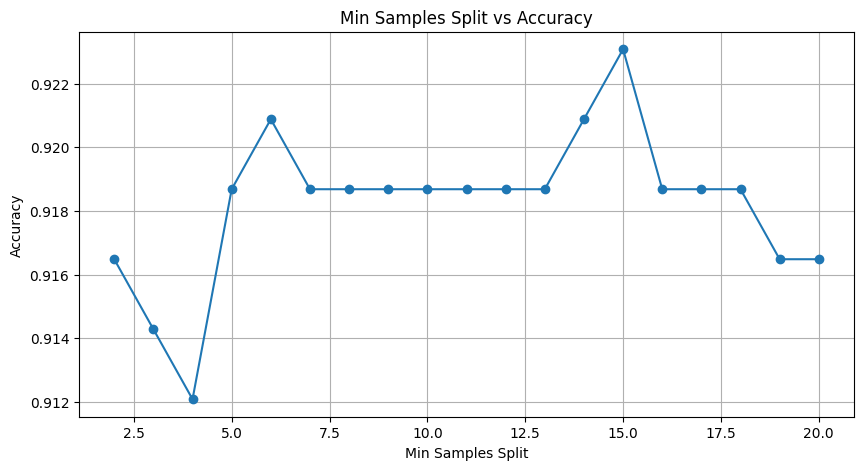

In [21]:
# Plot Min Samples Split v/s Accuracy

plt.figure(figsize=(10,5))
plt.plot(split_values, split_acc, marker="o")
plt.title("Min Samples Split vs Accuracy")
plt.xlabel("Min Samples Split")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

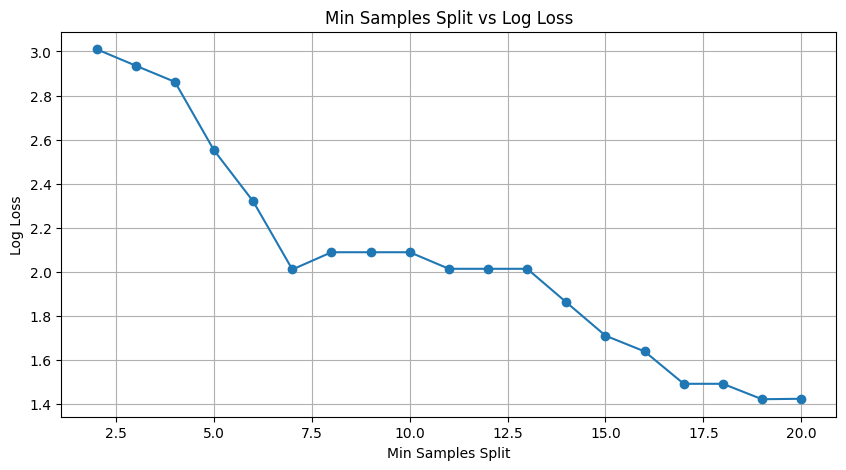

In [22]:
# Plot Min Samples Split v/s Loss

plt.figure(figsize=(10,5))
plt.plot(split_values, split_loss, marker="o")
plt.title("Min Samples Split vs Log Loss")
plt.xlabel("Min Samples Split")
plt.ylabel("Log Loss")
plt.grid()
plt.show()

## Write-Up
* Accuracy varies non-monotonically across different values of `min_samples_split`.
* Lower log loss indicates better probability predictions as always.
* Optimal value is selected based on `high accuracy` and `low log loss`.

# 10. Hyperparameter Study 5: `min_samples_leaf`
## (Minimum Samples Required at a Leaf)

## References
* Decision Tree Documentation

## Code

In [23]:
# Create range object for number of leaf samples
leaf_samples = range(1, 16)

# Create necessary data structures, again, I'm using lists
leaf_sample_acc = []
leaf_sample_loss = []

# Run main loop
for leaf in leaf_samples:

    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )

# Generate accuracy and loss and append to lists
    acc = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()

    loss = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_log_loss"
    ).mean()

    leaf_sample_acc.append(acc)
    leaf_sample_loss.append(loss)

    print(leaf, acc, loss)

1 0.9164835164835164 3.010239184146048
2 0.9142857142857144 2.3197653999032997
3 0.9208791208791209 1.4812157496169713
4 0.9340659340659341 1.3974416354490442
5 0.9274725274725275 1.4930452459665833
6 0.9230769230769231 1.5011550939635936
7 0.9230769230769231 1.4219055556642988
8 0.9164835164835166 1.4240417751048087
9 0.9142857142857144 1.4248919750029967
10 0.9142857142857143 1.196993940942577
11 0.9230769230769231 1.0411041888991834
12 0.9230769230769231 0.8984544978227504
13 0.9230769230769231 0.9071333336090163
14 0.9274725274725275 0.7637157541250876
15 0.9274725274725275 0.6881697869862403


## Code (Plots)

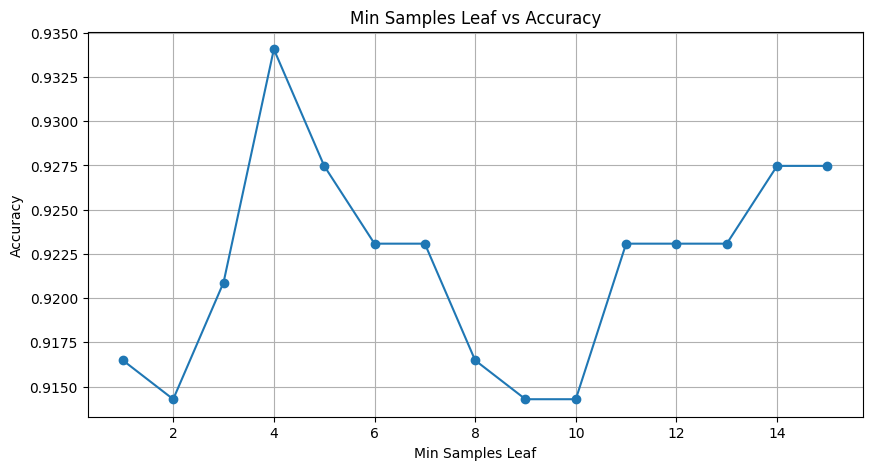

In [24]:
# Plot Min Samples Leaf v/s Accuracy

plt.figure(figsize=(10,5))
plt.plot(leaf_samples, leaf_sample_acc, marker="o")
plt.title("Min Samples Leaf vs Accuracy")
plt.xlabel("Min Samples Leaf")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

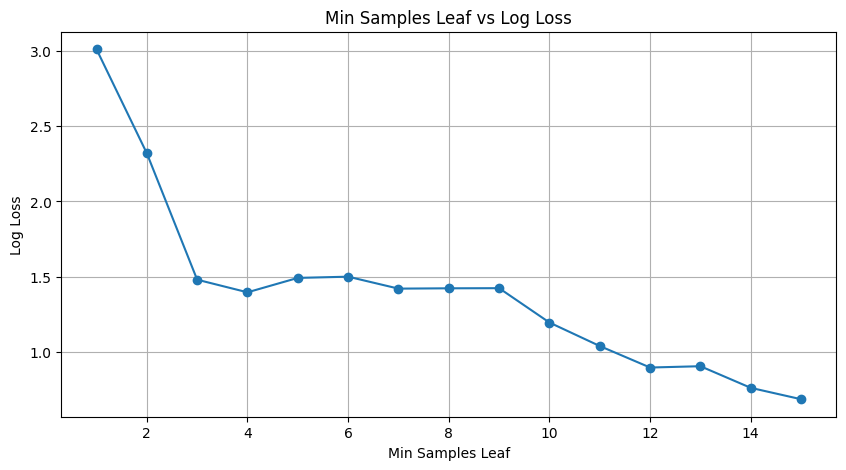

In [25]:
# Plot Min Samples Leaf v/s Loss

plt.figure(figsize=(10,5))
plt.plot(leaf_samples, leaf_sample_loss, marker="o")
plt.title("Min Samples Leaf vs Log Loss")
plt.xlabel("Min Samples Leaf")
plt.ylabel("Log Loss")
plt.grid()
plt.show()

## Write-Up
* Increasing leaf size reduces model complexity.
* Very large values may lead to underfitting.
* The best value again can be chosen based on validation metrics.

# 11. Summary of Hyperparameter Results

## References
* None

## Code

In [26]:
# Logic: Go into accuracy list
#        find the maximum accuracy
#        find corresponding index
#        pass it into hyperparameter list as index
# Same logic is applied to all of the below

# Find optimal criterion
best_criterion = criteria[np.argmax(criterion_acc)]

# Find optimal maximum depth
best_depth = depths[np.argmax(depth_acc)]

# Find optimal number of max leaf nodes
best_leaf_nodes = leaf_nodes[np.argmax(leaf_acc)]

# Find optimal number of minimum leaves at a node
best_min_split = split_values[np.argmax(split_acc)]

# Find optimal number of minimum samples at a leaf
best_min_leaf = leaf_samples[np.argmax(leaf_sample_acc)]

# Create a summary Dataframe and print it
summary = pd.DataFrame({
    "Hyperparameter": [
        "Criterion",
        "Max Depth",
        "Max Leaf Nodes",
        "Min Samples Split",
        "Min Samples Leaf"
    ],
    "Best Value": [
        best_criterion,
        best_depth,
        best_leaf_nodes,
        best_min_split,
        best_min_leaf
    ]
})

summary

,Hyperparameter,Best Value
0,Criterion,entropy
1,Max Depth,2
2,Max Leaf Nodes,3
3,Min Samples Split,15
4,Min Samples Leaf,4


## Write-Up
* Collected the best-performing value from each hyperparameter study.
* Provided a concise overview of tuning results.
* Those values will be used to build the final model.

# 12. Final Tuned Model

## References
* Decision Tree Classifier Documentation

## Code

In [27]:
# Now we know the optimum values of different hyperparameters
# Instead of training the model with just the baseline tree, I just have to use the obtained values
# Everything is whatever was done earlier itself, but manual assignment of hyperparameter values

final_tree = DecisionTreeClassifier(
    criterion=best_criterion,
    max_depth=best_depth,
    max_leaf_nodes=best_leaf_nodes,
    min_samples_split=best_min_split,
    min_samples_leaf=best_min_leaf,
    random_state=42
)

final_tree.fit(X_train, y_train)

y_pred = final_tree.predict(X_test)
y_prob = final_tree.predict_proba(X_test)

final_accuracy = accuracy_score(
    y_test,
    y_pred
)

final_loss = log_loss(
    y_test,
    y_prob
)

print("Final Accuracy:", final_accuracy)
print("Final Log Loss:", final_loss)

Final Accuracy: 0.9035087719298246
Final Log Loss: 0.22489535562390517


## Code (Final Tree Model Visualisation

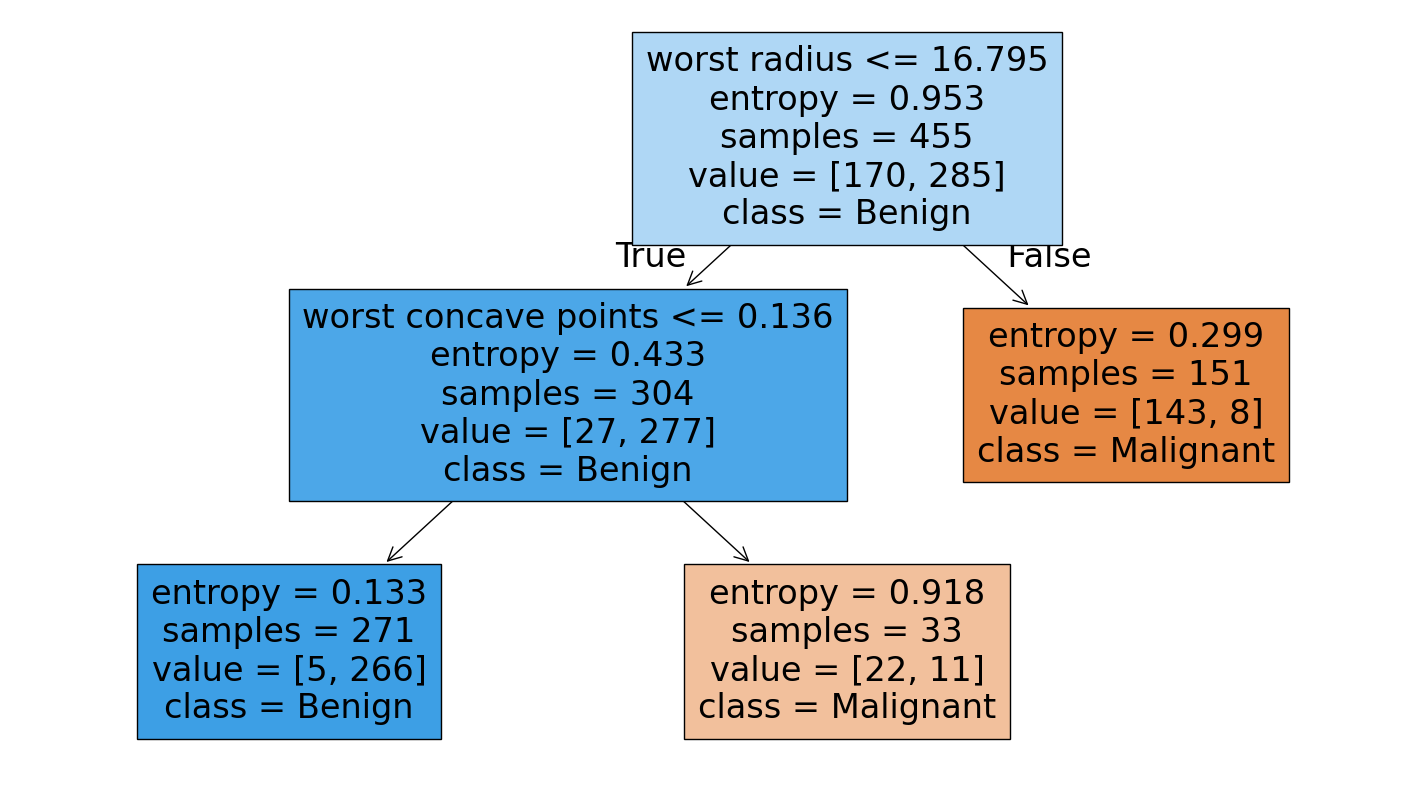

In [28]:
plt.figure(figsize=(18,10))
plot_tree(
    final_tree,
    filled=True,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"]
)
plt.show()

## Write-Up
* Constructed a decision tree using optimum values of each parameter.
* The tuned model performs better than baseline model.

# 13. General References
1. Scikit-Learn Documentation
2. DecisionTreeClassifier Documentation
3. Cross Validation Documentation
4. Breast Cancer Wisconsin Dataset Documentation
5. Pandas Documentation
6. Matplotlib Documentation